In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data Loading and Filtering for Vitamins

In [11]:
# Load the data
file_path = 'PoisonedOnly_NEISS_2004-2023.xlsx'
print(f"Loading data from {file_path}...")
df = pd.read_excel(file_path, sheet_name='ALL (DO NOT EDIT)', dtype=str)

Loading data from PoisonedOnly_NEISS_2004-2023.xlsx...


In [20]:
df.Treatment_Date

0        2004-01-04 00:00:00
1        2004-01-02 00:00:00
2        2004-01-02 00:00:00
3        2004-01-02 00:00:00
4        2004-01-02 00:00:00
                ...         
91350    2023-12-25 00:00:00
91351    2023-12-27 00:00:00
91352    2023-12-28 00:00:00
91353    2023-12-16 00:00:00
91354    2023-12-21 00:00:00
Name: Treatment_Date, Length: 91355, dtype: object

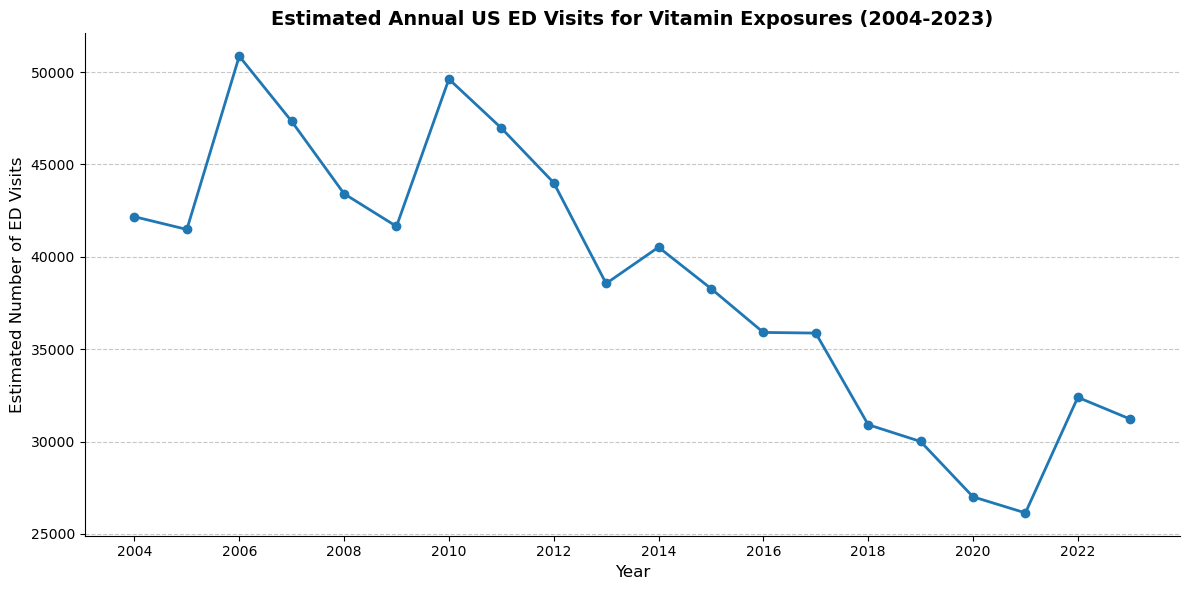

In [21]:
# Convert weights to numeric
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Extract the Year directly within the main dataframe
df['Treatment_Date'] = pd.to_datetime(df['Treatment_Date'], errors='coerce')
df['Year'] = df['Treatment_Date'].dt.year
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

# Create a new categorical column instead of a separate dataframe
vitamin_codes = ['1927', '1931', '1932']
df['Category'] = np.where(df['Product_1'].isin(vitamin_codes), 'Vitamins', 'Other Exposures')

# Group by Year and Category, then unstack to create two columns ('Vitamins' and 'Other Exposures')
# This completely bypasses the need for a 'df_vitamins' filter
yearly_data = df.groupby(['Year', 'Category'])['Weight'].sum().unstack(fill_value=0)

# --- 3. PLOT 1: VITAMINS ONLY (ABSOLUTE VOLUME) ---

plt.figure(figsize=(12, 6))
plt.plot(yearly_data.index, yearly_data['Vitamins'], 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=6)

plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


--- Indexed Trend Data (2004 = 100) ---
Category  Other Exposures    Vitamins
Year                                 
2004           100.000000  100.000000
2005           100.613966   98.366551
2006           102.441581  120.603744
2007           100.779823  112.241033
2008           102.323455  102.949823


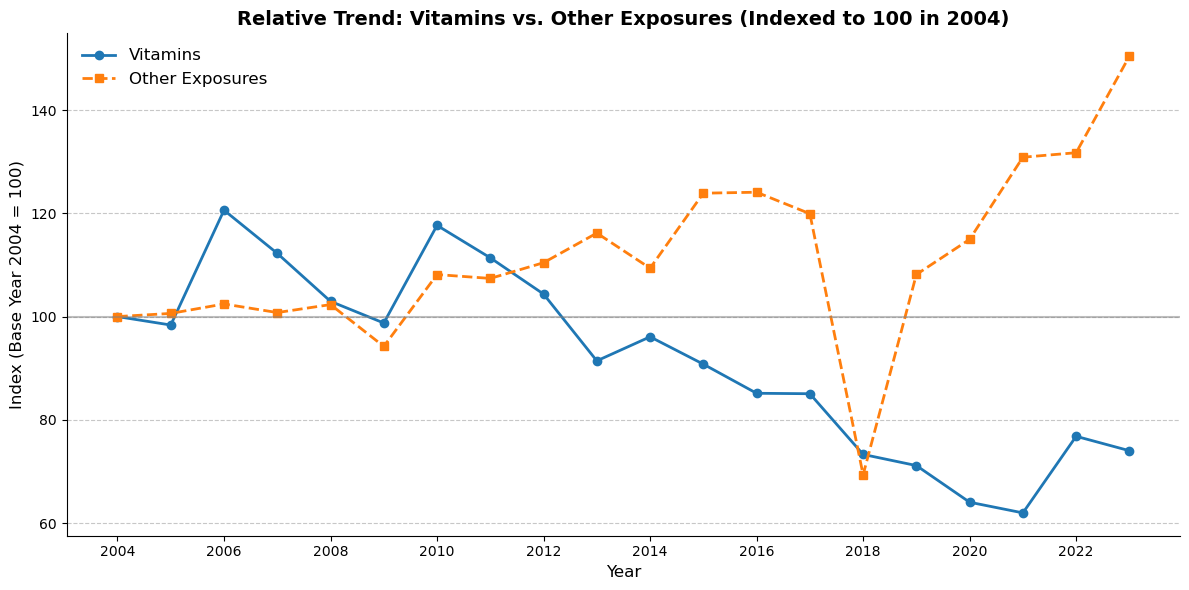

In [22]:
# --- 4. DATA INDEXING (BASE YEAR = 100) ---

# Identify the earliest year to use as the baseline (Index = 100)
base_year = yearly_data.index.min()

# Divide all years by the base year's value and multiply by 100
# This normalizes the data to show relative growth/decline
indexed_data = yearly_data.div(yearly_data.loc[base_year]) * 100

print("\n--- Indexed Trend Data (2004 = 100) ---")
print(indexed_data.head())

# --- 5. PLOT 2: COMPARATIVE INDEXED TREND ---

plt.figure(figsize=(12, 6))

# Plot both indexed trends on the same scale
plt.plot(indexed_data.index, indexed_data['Vitamins'], 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=6, label='Vitamins')
plt.plot(indexed_data.index, indexed_data['Other Exposures'], 
         marker='s', linestyle='--', linewidth=2, color='#ff7f0e', markersize=6, label='Other Exposures')

plt.title('Relative Trend: Vitamins vs. Other Exposures (Indexed to 100 in 2004)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Index (Base Year 2004 = 100)', fontsize=12)
plt.xticks(np.arange(min(indexed_data.index), max(indexed_data.index)+1, 2))

# Add a horizontal line at 100 to visually separate growth from decline
plt.axhline(y=100, color='gray', linestyle='-', alpha=0.5)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=False, fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


--- Average % Share of Annual ED Visits (by Month) ---
Category  Other Exposures  Vitamins
Month                              
1                    7.86      8.66
2                    7.53      7.50
3                    8.25      8.42
4                    8.07      7.86
5                    8.70      8.75
6                    8.57      8.28
7                    8.96      9.10
8                    9.15      8.69
9                    8.55      8.34
10                   8.62      8.24
11                   7.98      8.03
12                   7.74      8.14


NameError: name 'calendar' is not defined

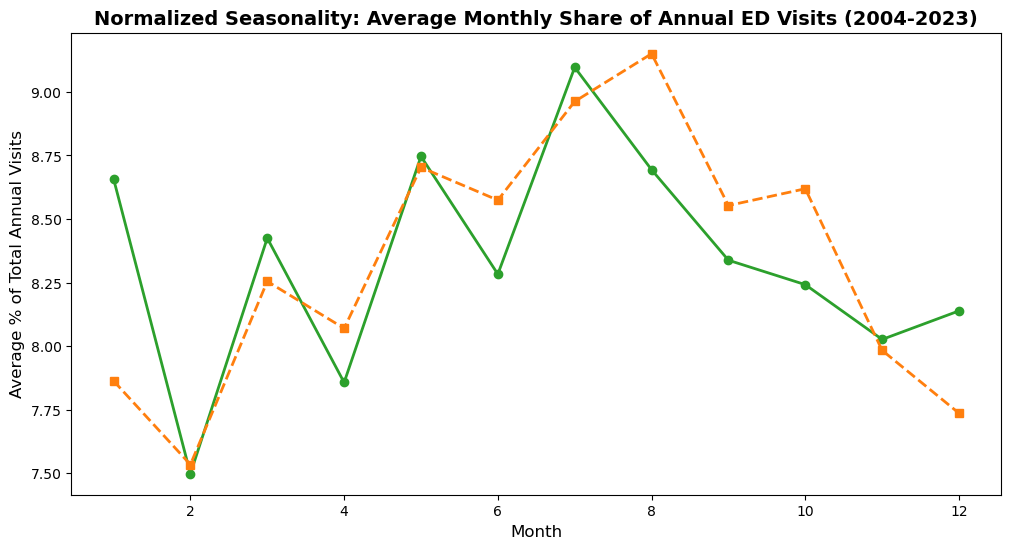

In [25]:
df['Year'] = df['Treatment_Date'].dt.year
df['Month'] = df['Treatment_Date'].dt.month

df = df.dropna(subset=['Year', 'Month'])
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Categorize without creating separate dataframes
vitamin_codes = ['1927', '1931', '1932']
df['Category'] = np.where(df['Product_1'].isin(vitamin_codes), 'Vitamins', 'Other Exposures')

# --- 3. NORMALIZED SEASONALITY CALCULATION ---

# Step A: Sum total ED visits for each specific Month of each Year
monthly_yearly_data = df.groupby(['Year', 'Month', 'Category'])['Weight'].sum().reset_index()

# Step B: Sum total ED visits for the entire Year
yearly_totals = monthly_yearly_data.groupby(['Year', 'Category'])['Weight'].sum().reset_index()
yearly_totals = yearly_totals.rename(columns={'Weight': 'Year_Total'})

# Step C: Merge and calculate the percentage share that each month contributes to its year
merged_data = pd.merge(monthly_yearly_data, yearly_totals, on=['Year', 'Category'])
merged_data['Month_Share_Pct'] = (merged_data['Weight'] / merged_data['Year_Total']) * 100

# Step D: Average these monthly percentages across all 20 years
final_seasonality = merged_data.groupby(['Month', 'Category'])['Month_Share_Pct'].mean().unstack()

print("\n--- Average % Share of Annual ED Visits (by Month) ---")
print(final_seasonality.round(2))

# --- 4. PLOTTING THE NORMALIZED SEASONALITY ---

plt.figure(figsize=(12, 6))

# Plot Vitamins
plt.plot(final_seasonality.index, final_seasonality['Vitamins'], 
         marker='o', color='#2ca02c', linewidth=2, label='Vitamins')

# Plot Other Exposures
plt.plot(final_seasonality.index, final_seasonality['Other Exposures'], 
         marker='s', linestyle='--', color='#ff7f0e', linewidth=2, label='Other Exposures')

# Formatting
plt.title('Normalized Seasonality: Average Monthly Share of Annual ED Visits (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average % of Total Annual Visits', fontsize=12)

# Set X-axis to display month names properly using the 'calendar' library
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:13])

# Add a baseline horizontal line (100% / 12 months = 8.33%)
plt.axhline(y=100/12, color='gray', linestyle=':', alpha=0.8, 
            label='Baseline (8.33% - Even Distribution)')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=False, fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()